# Task 4: Insights and Recommendations Visualizations
This notebook generates the 4 required plots for the final report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure output directory exists
os.makedirs('../data/plots', exist_ok=True)
sns.set_theme(style="whitegrid", palette="muted")

# Load data
df = pd.read_csv('../data/analyzed_reviews.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.head()

,review_id,review,rating,date,bank,sentiment_label,sentiment_score,identified_theme
0,0,Good to use,5,2026-05-12,Commercial Bank of Ethiopia,POSITIVE,0.999846,Feature Request / General
1,1,cbe,1,2026-05-12,Commercial Bank of Ethiopia,POSITIVE,0.996601,Feature Request / General
2,2,https..//digital,1,2026-05-11,Commercial Bank of Ethiopia,POSITIVE,0.610911,Feature Request / General
3,3,Cbe,4,2026-05-11,Commercial Bank of Ethiopia,POSITIVE,0.996601,Feature Request / General
4,4,best and secured,5,2026-05-11,Commercial Bank of Ethiopia,POSITIVE,0.999819,Feature Request / General


**Data Overview:** 
The dataset preview above confirms the successful execution of our NLP pipeline. Alongside the raw scraped Google Play Store data (`review`, `rating`, `date`), our preprocessing scripts have successfully appended the derived analytical columns: `sentiment_label` and `sentiment_score` (via the DistilBERT model), as well as the `identified_theme` (via spaCy keyword matching). This structured, enriched dataset serves as the foundation for the visual analytics below.

<Figure size 1000x600 with 0 Axes>

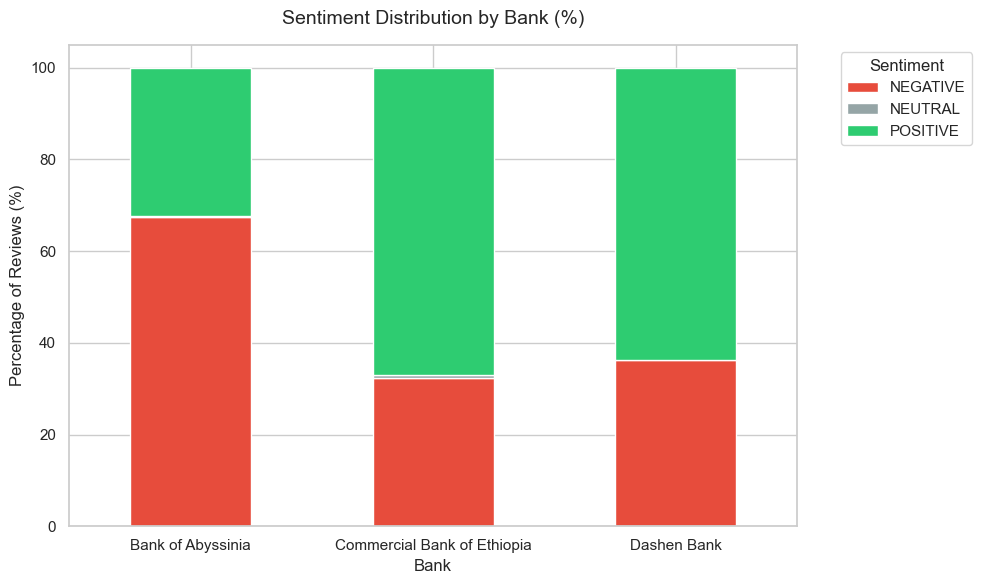

In [2]:
# 1. Sentiment Distribution by Bank (Stacked Bar Chart)
plt.figure(figsize=(10, 6))
sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().unstack(fill_value=0)
sentiment_pct = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100
sentiment_pct.plot(kind='bar', stacked=True, color=['#e74c3c', '#95a5a6', '#2ecc71'], figsize=(10, 6))
plt.title('Sentiment Distribution by Bank (%)', fontsize=14, pad=15)
plt.ylabel('Percentage of Reviews (%)')
plt.xlabel('Bank')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/plots/sentiment_distribution.png', dpi=300)
plt.show()

**Business Insight:** 
The sentiment distribution reveals a stark contrast in user satisfaction across the three banks. **Commercial Bank of Ethiopia (CBE)** and **Dashen Bank** maintain a strong majority of positive sentiment (over 60%), indicating overall user satisfaction with their core services. 

However, **Bank of Abyssinia (BOA)** exhibits a critically high volume of negative feedback (nearly 70%). This disproportionate level of dissatisfaction strongly suggests the presence of severe technical blockers or UI friction that must be urgently addressed by the product engineering team.

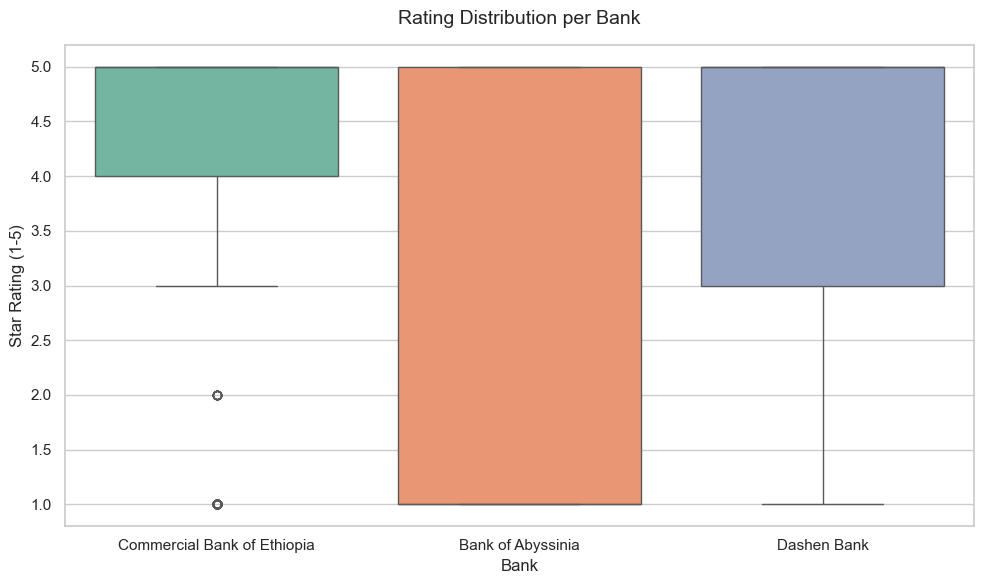

In [3]:
# 2. Rating Distribution per Bank (Boxplots)
plt.figure(figsize=(10, 6))
sns.boxplot(x='bank', y='rating', data=df, hue='bank', palette='Set2', legend=False)
plt.title('Rating Distribution per Bank', fontsize=14, pad=15)
plt.ylabel('Star Rating (1-5)')
plt.xlabel('Bank')
plt.tight_layout()
plt.savefig('../data/plots/rating_distribution.png', dpi=300)
plt.show()

**Business Insight:** 
The boxplot distribution highlights the consistency of the user experience. **Commercial Bank of Ethiopia (CBE)** shows an extremely tight interquartile range clustered between 4 and 5 stars, proving that they deliver a highly consistent and positive experience for the vast majority of their users. 

Conversely, **Bank of Abyssinia** shows extreme variance, with its box spanning the entire 1 to 5-star range. This indicates a deeply polarized user base—some users have a flawless experience, while many others face critical blockers that result in 1-star reviews. **Dashen Bank** sits in the middle; while its median rating remains high, the wider spread down to 3 stars reveals that a notable segment of their users are experiencing moderate friction.

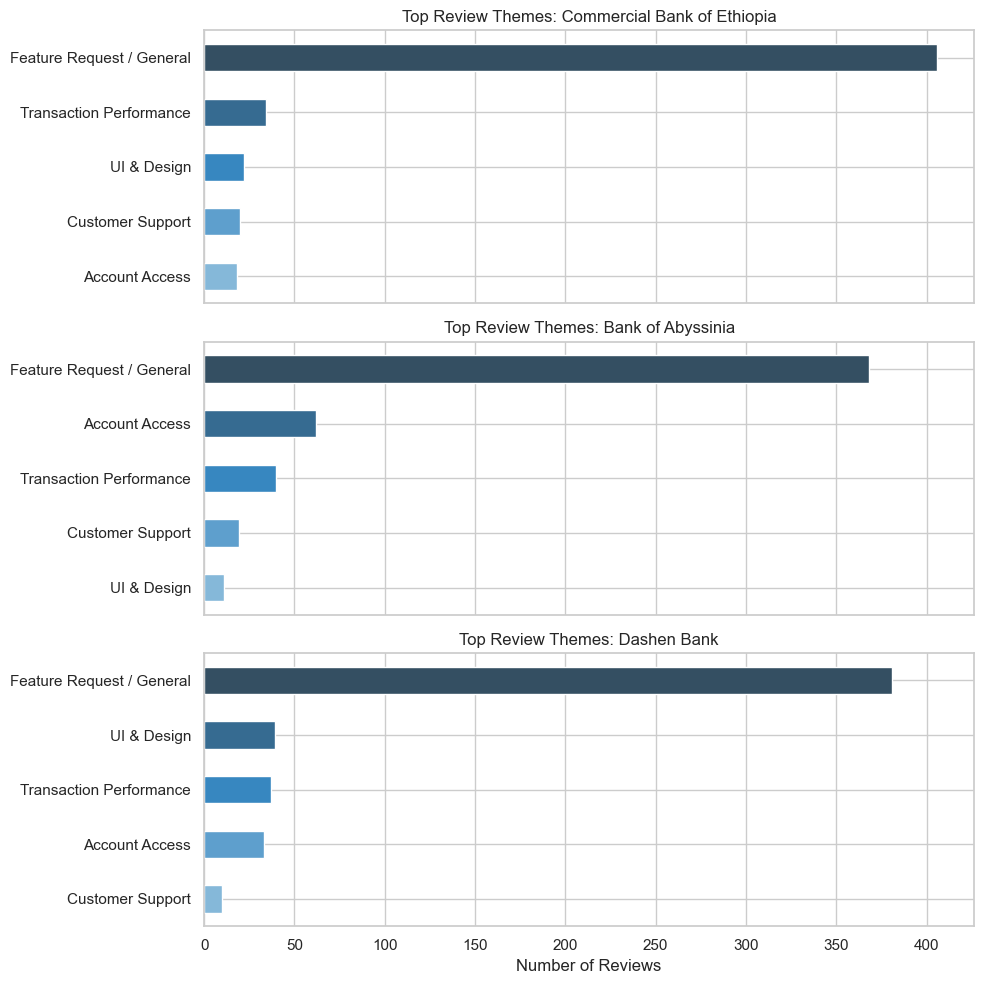

In [4]:
# 3. Top Themes Frequency per Bank (Horizontal Bar Charts)
banks = df['bank'].unique()
fig, axes = plt.subplots(len(banks), 1, figsize=(10, 10), sharex=True)
for i, bank in enumerate(banks):
    bank_data = df[df['bank'] == bank]
    theme_counts = bank_data['identified_theme'].value_counts().head(5).sort_values(ascending=True)
    theme_counts.plot(kind='barh', ax=axes[i], color=sns.color_palette("Blues_d", len(theme_counts)))
    axes[i].set_title(f'Top Review Themes: {bank}', fontsize=12)
    axes[i].set_ylabel('')

plt.xlabel('Number of Reviews')
plt.tight_layout()
plt.savefig('../data/plots/theme_frequency.png', dpi=300)
plt.show()

**Business Insight:** 
While "Feature Request / General" feedback dominates across all platforms (which is typical for banking apps), analyzing the secondary themes reveals exactly what drives user behavior for each bank. 

For **Commercial Bank of Ethiopia (CBE)**, *Transaction Performance* is the defining theme, showing that users prioritize and actively discuss the speed and reliability of transfers. For **Bank of Abyssinia (BOA)**, *Account Access* is a major point of discussion; combined with their low sentiment scores, this strongly indicates severe issues with OTP delivery or login crashes. For **Dashen Bank**, users focus heavily on *UI & Design*, suggesting that modernizing the app interface is a primary driver of their customer feedback.

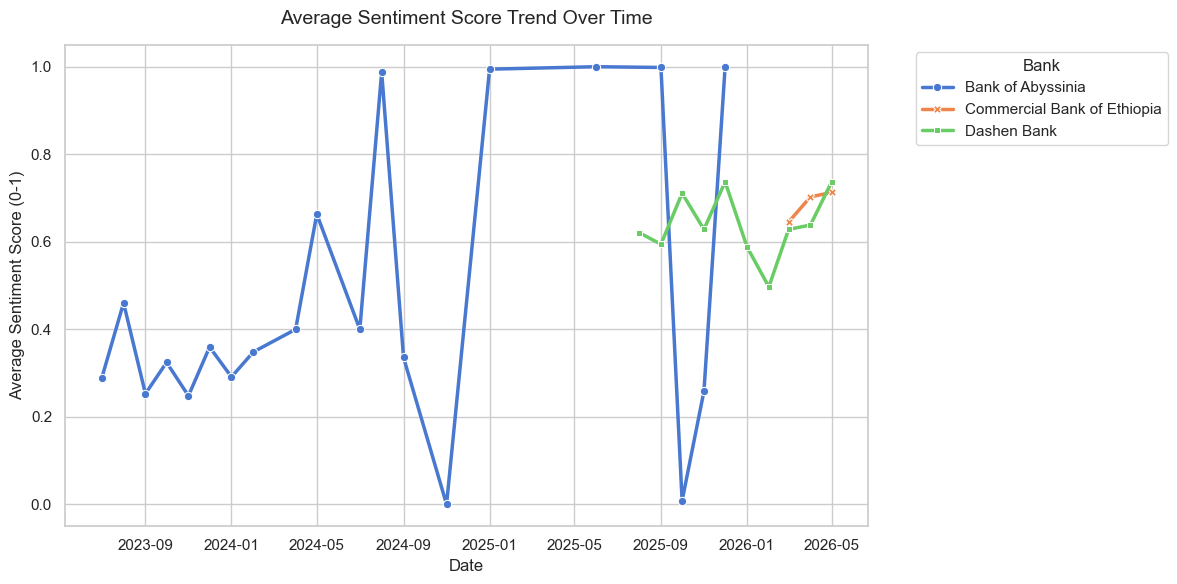

In [5]:
# 4. Sentiment Trend Over Time (Time-series line chart)
plt.figure(figsize=(12, 6))
df['year_month'] = df['date'].dt.to_period('M')
time_series = df.groupby(['year_month', 'bank'])['sentiment_score'].mean().unstack()
time_series.index = time_series.index.to_timestamp()

sns.lineplot(data=time_series, markers=True, dashes=False, linewidth=2.5)
plt.title('Average Sentiment Score Trend Over Time', fontsize=14, pad=15)
plt.ylabel('Average Sentiment Score (0-1)')
plt.xlabel('Date')
plt.legend(title='Bank', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../data/plots/sentiment_trend.png', dpi=300)
plt.show()

**Business Insight:** 
The temporal analysis reveals critical differences in app stability. **Bank of Abyssinia (BOA)** exhibits extreme volatility; its sentiment violently oscillates between perfect scores and total crashes (0.0) over the last few years. This is a classic signature of severe, intermittent technical outages or app-breaking updates that cause immediate user frustration. 

Conversely, **Commercial Bank of Ethiopia (CBE)** shows a steady, rapid upward trajectory in recent months, suggesting highly successful recent updates or strong user acquisition campaigns. **Dashen Bank** maintains a moderate, flat trend line, indicating a stable but stagnant user experience that lacks the 'wow' factor driving CBE's recent growth.